<a href="https://colab.research.google.com/github/giumont/overlap_resolver/blob/main/notebooks/DNN_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT FILE DATI DA GOOGLE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# IMPORT GITHUB REPO: flavour_tag_ml (repo "flavour_tagging")

from google.colab import userdata
import os
import sys

token = userdata.get("GITHUB_TOKEN")

REPO_PATH_FLAVOUR_TAG_ML = "/content/flavour_tagging"

if not os.path.exists(REPO_PATH_FLAVOUR_TAG_ML):
    !git clone https://{token}@github.com/giumont/flavour_tagging.git {REPO_PATH_FLAVOUR_TAG_ML}
else:
    !git -C {REPO_PATH_FLAVOUR_TAG_ML} pull --rebase

# The importable package lives under <repo>/src/flavour_tag_ml, so we add
# <repo>/src (not the repo root) to sys.path and import it as a top-level
# package: "import flavour_tag_ml".
SRC_PATH_FLAVOUR_TAG_ML = os.path.join(REPO_PATH_FLAVOUR_TAG_ML, "src")
if SRC_PATH_FLAVOUR_TAG_ML not in sys.path:
    sys.path.append(SRC_PATH_FLAVOUR_TAG_ML)

import flavour_tag_ml


Cloning into '/content/flavour_tagging'...
remote: Enumerating objects: 960, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 960 (delta 73), reused 93 (delta 39), pack-reused 815 (from 2)
Receiving objects: 100% (960/960), 156.50 MiB | 18.99 MiB/s, done.
Resolving deltas: 100% (508/508), done.


In [3]:
# IMPORT GITHUB REPO: overlap_resolver
#
# Contains, under "src/": obj_3_1.py, overlap_kinematics.py,
# truth_vs_reco_params.py and overlap_pairs_dataset_builder.py (this
# notebook's main orchestrator).

token_overlap = userdata.get("GITHUB_TOKEN_OVERLAP_RESOLVER")

REPO_PATH_OVERLAP_RESOLVER = "/content/overlap_resolver"

if not os.path.exists(REPO_PATH_OVERLAP_RESOLVER):
    !git clone https://{token_overlap}@github.com/giumont/overlap_resolver.git {REPO_PATH_OVERLAP_RESOLVER}
else:
    !git -C {REPO_PATH_OVERLAP_RESOLVER} pull --rebase

# Unlike flavour_tag_ml, the modules under overlap_resolver/src are FLAT:
# they import each other directly (e.g. overlap_kinematics.py does
# "from obj_3_1 import ..." and "from truth_vs_reco_params import ...",
# NOT "from src.obj_3_1 import ..."). To keep them working unmodified, we
# append the "src" folder ITSELF to sys.path (not the repo root), and
# import them below as flat top-level modules.
SRC_PATH_OVERLAP_RESOLVER = os.path.join(REPO_PATH_OVERLAP_RESOLVER, "src")
if SRC_PATH_OVERLAP_RESOLVER not in sys.path:
    sys.path.append(SRC_PATH_OVERLAP_RESOLVER)


Cloning into '/content/overlap_resolver'...
remote: Enumerating objects: 1523, done.
remote: Counting objects: 100% (324/324), done.
remote: Compressing objects: 100% (221/221), done.
remote: Total 1523 (delta 139), reused 261 (delta 81), pack-reused 1199 (from 1)
Receiving objects: 100% (1523/1523), 776.99 MiB | 18.79 MiB/s, done.
Resolving deltas: 100% (608/608), done.
Updating files: 100% (955/955), done.


In [4]:
# IMPORT FILE PROGETTO DA GITHUB

from flavour_tag_ml.data import JetDataset, build_jet_features, extract_balanced_subset, compute_feature_stats
from flavour_tag_ml.merge_datasets import merge_checkpoint_chunks, check_checkpoint_progress

from flavour_tag_ml.models import create_model
from flavour_tag_ml.training import CategoricalFocalLoss, run_epoch, get_predictions, train_model, create_dataloaders

from flavour_tag_ml.utils import set_seed, load_mmap, save_run_outputs, build_metrics_report, run_evaluation_suite,  write_metrics_report, save_run_arrays, count_model_parameters
from flavour_tag_ml.graphics import plot_ovr_roc_curves, plot_multiclass_score_distribution, plot_multiclass_confusion_matrix, apply_atlas_style,  compute_multiclass_classification_metrics, compute_ovr_working_points

In [5]:
# To reload imported files if they have been modified during runtime

import importlib
import flavour_tag_ml.data
import flavour_tag_ml.models
import flavour_tag_ml.training
import flavour_tag_ml.graphics
import flavour_tag_ml.utils

importlib.reload(flavour_tag_ml.data)
importlib.reload(flavour_tag_ml.merge_datasets)
importlib.reload(flavour_tag_ml.models)
importlib.reload(flavour_tag_ml.training)
importlib.reload(flavour_tag_ml.graphics)
importlib.reload(flavour_tag_ml.utils)

#from flavour_tag_ml.utils import build_jet_features

<module 'flavour_tag_ml.utils' from '/content/flavour_tagging/src/flavour_tag_ml/utils.py'>

In [6]:
# IMPORT PYTHON LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# sposta file in memoria locale colab
#!cp /content/drive/MyDrive/obj_2/*.h5 /content/

In [21]:
#################################################################
# GLOBAL PARAMS
#################################################################

# FILES
#DATASETS_DIR = '/content/' #gpu
#INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/HH_bbtt" #cpu
INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/bkg_tt" #cpu


TRAINSET_X_NAME = 'X_train_normalized.npy'
TRAINSET_Y_NAME = 'y_train_normalized.npy'

VALSET_X_NAME   = 'X_val_normalized.npy'
VALSET_Y_NAME   = 'y_val_normalized.npy'

TESTSET_X_NAME  = 'X_test_normalized.npy'
TESTSET_Y_NAME = 'y_test_normalized.npy'

#CHECK_LOAD_FILENAME = 'train_normalization_params.npz' # file with weights and feature_names (available for full, not reduced dataset)
CHECK_LOAD_FILENAME = "pair_feature_names.npz"

# DATASET
N_TRAIN = None
N_VAL   = None
N_TEST  = None

# OUTPUT_DIR = '/content/drive/MyDrive/flavour_tagging/obj_2/datas/np_arrays/MC23G_dataset'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_DIR = None

SUB_TRAINSET_NAME = None
SUB_VALSET_NAME = None
SUB_TESTSET_NAME = None

# PROBLEM DEFINITION
NUM_CLASSES = 4 # FF=0, FT=1, TF=2, TT=3
CLASS_NAMES = ["FF", "FT", "TF", "TT"]  # ordine coerente con le label 0,1,2,3

TASK = "multiclass" if NUM_CLASSES > 2 else "binary"

# RETE
HIDDEN_DIMS = (32, 16)

ACTIV_FUNC = nn.ReLU()
NORM_LAYER = nn.LayerNorm

DROPOUT = 0.1 # percentuale neuroni disattivati randomicamente: riduce overfitting

MODEL_CONFIG = {
    "name": "MLPMultiTagger",
    "hidden_dims": HIDDEN_DIMS,
    "num_classes": NUM_CLASSES,
    "norm_layer": NORM_LAYER,
    "dropout": DROPOUT,
}

# TRAINING
BEST_MODEL_FOR_VALIDATION = True # False: salva a prescindere i weights dell'ultima epoca; True: previene overfitting
BEST_MODEL_METRIC = "ap_macro" # "mean" / "median" / "f1_macro" / "ap_macro": quale metrica su val viene considerata per aggiornare best_model

SAMPLING_STRATEGY = "none" # "none" / "oversample" / "undersample"

CRITERION = CategoricalFocalLoss()
WEIGHTED_LOSS = True

LR = 1e-3 # learning rate ottimizzatore
WEIGHT_DECAY = 1e-4  # regolarizzazione L2 nell'ottimizzatore

OPTIMIZER_CONFIG = {
    "name": "AdamW",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
}

SCHEDULER_FACTOR = 0.7
SCHEDULER_PATIENCE = 5

SCHEDULER_CONFIG = {
    "name": "ReduceLROnPlateau",
    "factor": SCHEDULER_FACTOR,
    "patience": SCHEDULER_PATIENCE,
    "mode": "max"   # "max" must be used with "f1_macro" / "ap_macro" metrics
}

BATCH_SIZE = 2048
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

MIN_DELTA_VAL_LOSS = 1e-4 # soglia minima miglioramento loss su valset tra due epoche

# Suffisso comune per i nomi dei file salvati (architettura + training)
RUN_TAG = (
    f"{len(HIDDEN_DIMS)}layers_"
    f"{'_'.join(str(h) for h in HIDDEN_DIMS)}_"
    f"dropout{DROPOUT}_{NORM_LAYER.__name__}_batch{BATCH_SIZE}"
    f"_lr{LR}_wd{WEIGHT_DECAY}"
    f"_best_on_{BEST_MODEL_METRIC}"
    f"_criterion_{CRITERION}"
    f"_weight_loss_{WEIGHTED_LOSS}"
    f"_sampling_strategy_{SAMPLING_STRATEGY}"
)

# Store weights: nome/percorso generati automaticamente da RUN_TAG,
MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/HH_bbtt_dataset'
#MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/bkg_tt_dataset'

os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_NAME = f"best_model_{RUN_TAG}.pt"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

CHECKPOINT_NAME = f"checkpoint_{RUN_TAG}.pt"
CHECKPOINT_PATH = os.path.join(MODEL_DIR, CHECKPOINT_NAME)

# GRAPHICS
GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/HH_bbtt_dataset"
#GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/bkg_tt_dataset"
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# GITHUB
#GIT_OUTPUT_DIR = "DNN/HH_bbtt_dataset"
GIT_OUTPUT_DIR = "DNN/bkg_tt_dataset"

# OTHER
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# SET GLOBAL SEED
set_seed(RANDOM_SEED)

In [9]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


In [9]:
# LOADING INPUT

X_train = load_mmap(INPUT_DIR, TRAINSET_X_NAME)
y_train = load_mmap(INPUT_DIR, TRAINSET_Y_NAME)

X_val = load_mmap(INPUT_DIR, VALSET_X_NAME)
y_val = load_mmap(INPUT_DIR, VALSET_Y_NAME)

X_test = load_mmap(INPUT_DIR, TESTSET_X_NAME)
y_test = load_mmap(INPUT_DIR, TESTSET_Y_NAME)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(71696, 21) (71696,)
(15334, 21) (15334,)
(15438, 21) (15438,)


In [10]:
# WEIGHTS PER LOSS PESATA - GESTIONE IMBALANCE CLASSI

if WEIGHTED_LOSS:
  # Class weighting per gestire l'imbalance (FF 10.1%, FT 73.1%, TF 16.1%, TT 0.65%).
  # Calcolati SOLO sul train set (mai su val/test).
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()
  CLASS_WEIGHTS = train_class_counts.sum() / (NUM_CLASSES * train_class_counts)
  CLASS_WEIGHTS = CLASS_WEIGHTS.to(DEVICE)

  if isinstance(CRITERION, nn.CrossEntropyLoss):
    CRITERION.weight=CLASS_WEIGHTS
  elif isinstance(CRITERION, CategoricalFocalLoss):
    CRITERION.alpha=CLASS_WEIGHTS
  else:
    raise ValueError("The specified criterion is not available.")

else:
  CLASS_WEIGHTS = None

/tmp/ipykernel_3320/87765587.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()


In [11]:
# PARAMETRI DI RETE / TRAINING DA ANNOTARE SUI GRAFICI

PLOT_PARAMS = {
    "n_overlap_couples": int(X_train.shape[0]),
    "n_features": int(X_train.shape[1]),
    "class_names": CLASS_NAMES,
    "hidden_dims": HIDDEN_DIMS,
    "norm_layer": NORM_LAYER.__name__,
    "activation": ACTIV_FUNC.__class__.__name__,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "best_model_metric": BEST_MODEL_METRIC,
    "sampling_strategy": SAMPLING_STRATEGY,
    "criterion": CRITERION,
    "class_weights": CLASS_WEIGHTS,

}


In [ ]:
# Extraction of balanced subOUTPUT of required dimensions

X_train, y_train = extract_balanced_subset(X_train, y_train, N_TRAIN, seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TRAINSET_NAME)
X_val,   y_val   = extract_balanced_subset(X_val,   y_val,   N_VAL,   seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_VALSET_NAME)
X_test,  y_test  = extract_balanced_subset(X_test,  y_test,  N_TEST,  seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TESTSET_NAME)

print("Train:", X_train.shape, y_train.shape, "| bilanciamento:", y_train.mean())
print("Val:  ", X_val.shape,   y_val.shape,   "| bilanciamento:", y_val.mean())
print("Test: ", X_test.shape,  y_test.shape,  "| bilanciamento:", y_test.mean())

NameError: name 'X_train' is not defined

In [ ]:
# # CHECK - VERIFY RELOAD CORRECTNESS

# if CHECK_LOAD_FILENAME is None:
#     print("INFO - CHECK_LOAD_FILENAME non specificato: salto il caricamento dei parametri di normalizzazione e dei nomi features.")
#     mean = std = train_feature_names = None

# else:
#     norm_params_path = os.path.join(INPUT_DIR, CHECK_LOAD_FILENAME)

#     if os.path.exists(norm_params_path):
#         norm_params_npz = np.load(norm_params_path, allow_pickle=True)

#         print(f"Chiavi in {CHECK_LOAD_FILENAME}:", norm_params_npz.files)

#         mean = norm_params_npz['mean']
#         std = norm_params_npz['std']
#         train_feature_names = norm_params_npz['feature_names']

#         print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#         print("N. feature names:", len(train_feature_names))
#         print("Esempio:", train_feature_names[:3])

#     else:
#         print(f"INFO - '{norm_params_path}' non trovato: salto i controlli su mean/std/feature_names salvati.")
#         mean = std = train_feature_names = None


# print("\n=== SHAPES ===")
# print("X_train:", X_train.shape, "| y_train:", y_train.shape)
# print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
# print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

# # Coerenza numero campioni X <-> y, per ogni split
# assert len(X_train) == len(y_train), "Mismatch train X/y!"
# assert len(X_val) == len(y_val), "Mismatch val X/y!"
# assert len(X_test) == len(y_test), "Mismatch test X/y!"

# # Stessa dimensionalità delle feature in tutti gli split
# n_features = X_train.shape[1]
# assert X_val.shape[1] == n_features, "Val ha un numero di feature diverso dal train!"
# assert X_test.shape[1] == n_features, "Test ha un numero di feature diverso dal train!"

# if train_feature_names is not None:
#     print("\n=== FEATURE NAMES (da train_normalization_params.npz) ===")
#     print("N. nomi:", len(train_feature_names), "| N. colonne X:", n_features)
#     assert len(train_feature_names) == n_features, "feature_names non combacia col numero di colonne!"
#     print("Primi 3:", train_feature_names[:3])
#     print("Ultimi 3:", train_feature_names[-3:])

#     print("\n=== NORMALIZZAZIONE (mean/std salvati) ===")
#     print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#     assert mean.shape[0] == n_features and std.shape[0] == n_features, "mean/std non combaciano col numero di feature!"

# print("\n=== BILANCIAMENTO CLASSI ===")
# print("Train:", y_train.mean())
# print("Val:  ", y_val.mean())
# print("Test: ", y_test.mean())

# print("\n=== NaN / Inf SU CAMPIONE (evita di leggere l'intero memmap da disco) ===")
# sample_size = 200_000
# for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
#     n = min(sample_size, len(arr))
#     idx = np.sort(np.random.choice(len(arr), size=n, replace=False))
#     sample = arr[idx]
#     n_nan = np.isnan(sample).sum()
#     n_inf = np.isinf(sample).sum()
#     print(f"{name} (campione di {n}): NaN={n_nan}, Inf={n_inf}")
#     assert n_nan == 0 and n_inf == 0, f"{name} contiene NaN/Inf nel campione controllato!"

# print("\n=== SINGOLO CAMPIONE (X_train[0], y_train[0]) ===")
# x_sample, y_sample = X_train[0], y_train[0]
# print("Shape singolo campione X:", np.shape(x_sample), "| dtype:", np.asarray(x_sample).dtype)
# print("Shape singolo campione y:", np.shape(y_sample), "| dtype:", np.asarray(y_sample).dtype)

# print("\nTutti i controlli superati (su campionamento per gli split memory-mapped).")

# # Mean and std on datasets
# mean_train, std_train = compute_feature_stats(X_train)
# mean_val,   std_val   = compute_feature_stats(X_val)
# mean_test,  std_test  = compute_feature_stats(X_test)


# print("\n================ NORMALIZATION CHECK ================\n")

# print("TRAIN")
# print(f"  mean range: [{mean_train.min():.6f}, {mean_train.max():.6f}]")
# print(f"  std  range: [{std_train.min():.6f}, {std_train.max():.6f}]")

# print("\nVAL")
# print(f"  mean range: [{mean_val.min():.6f}, {mean_val.max():.6f}]")
# print(f"  std  range: [{std_val.min():.6f}, {std_val.max():.6f}]")

# print("\nTEST")
# print(f"  mean range: [{mean_test.min():.6f}, {mean_test.max():.6f}]")
# print(f"  std  range: [{std_test.min():.6f}, {std_test.max():.6f}]")

Chiavi in pair_feature_names.npz: ['feature_names', 'label_index_map', 'dr_thr']


KeyError: 'mean is not a file in the archive'

In [11]:
# Dataset Pytorch

train_dataset = JetDataset(X_train, y_train, task=TASK)
val_dataset = JetDataset(X_val, y_val, task=TASK)
test_dataset = JetDataset(X_test, y_test, task=TASK)

# Check type is matched with the type of loss function used
assert train_dataset.y.dtype == (torch.long if TASK == "multiclass" else torch.float32)
assert set(torch.unique(train_dataset.y).tolist()) <= set(range(NUM_CLASSES))

In [12]:
# DataLoader pytorch — ora tramite create_dataloaders, che espone
# sampling_strategy ("none" / "oversample" / "undersample") invece
# dello shuffle=True fisso di prima.
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=BATCH_SIZE,
    num_classes=NUM_CLASSES,
    sampling_strategy=SAMPLING_STRATEGY,
    num_workers=2,
)


In [13]:
# Modello
model = create_model(MODEL_CONFIG, input_dim=X_train.shape[1])

In [13]:
# Optimizer e scheduler creati internamente da train_model a partire
# dai config dict (OPTIMIZER_CONFIG, SCHEDULER_CONFIG)
model, train_losses, val_losses = train_model(
    train_loader,
    val_loader,
    model,
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    criterion=CRITERION,
    max_epochs=MAX_EPOCHS,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    best_model_for_validation=BEST_MODEL_FOR_VALIDATION,
    model_selection_metric=BEST_MODEL_METRIC,
    model_path=MODEL_PATH,
    device=DEVICE,
    reset_weights=True,
    checkpoint_path=CHECKPOINT_PATH,
    resume_from_checkpoint=False,
)

KeyboardInterrupt: 

In [ ]:
# import shutil, os, time

# LOCAL_PATH = '/content/local_data'
# os.makedirs(LOCAL_PATH, exist_ok=True)

# files_to_copy = [
#     'X_train_normalized.npy', 'y_train_normalized.npy',
#     'X_val_normalized.npy',   'y_val_normalized.npy',
# ]

# for f in files_to_copy:
#     src = os.path.join(DATASETS_DIR, f)
#     dst = os.path.join(LOCAL_PATH, f)
#     if not os.path.exists(dst):
#         t0 = time.time()
#         shutil.copy(src, dst)
#         print(f"{f}: copiato in {time.time()-t0:.1f}s")
#     else:
#         print(f"{f}: già presente")

In [ ]:
# def load_mmap_local(name):
#     return np.load(os.path.join(LOCAL_PATH, name), mmap_mode='r')

# X_train = load_mmap_local('X_train_normalized.npy')
# y_train = load_mmap_local('y_train_normalized.npy')
# X_val   = load_mmap_local('X_val_normalized.npy')
# y_val   = load_mmap_local('y_val_normalized.npy')

# train_dataset_partial = JetDataset(X_train, y_train)
# val_dataset_partial   = JetDataset(X_val, y_val)

In [ ]:
# import time
# t0 = time.time()
# for i, (xb, yb) in enumerate(train_loader):
#     if i == 50:
#         break
# t1 = time.time()
# print(f"Tempo per 50 step: {t1-t0:.1f}s -> stima per epoca: {(t1-t0)/50 * len(train_loader):.1f}s")

In [12]:
#################################################################
# VALUTAZIONE MODELLO + SALVATAGGIO OUTPUT (FIGURE + CONFIG + DATI) SULLA REPO GITHUB
#################################################################
ATLAS_STYLE = True                          # oppure False se non hai mplhep installato
BACKGROUND_REJECTION_EFF_RANGE = (0.2, 1.0) # range realistico per il plot principale
WORKING_POINT_TARGETS = (0.70, 0.75, 0.80, 0.85, 0.90, 0.97)

config = {
    "data": {
        "input_dir": INPUT_DIR,
        "trainset_x_name": TRAINSET_X_NAME,
        "trainset_y_name": TRAINSET_Y_NAME,
        "valset_x_name": VALSET_X_NAME,
        "valset_y_name": VALSET_Y_NAME,
        "testset_x_name": TESTSET_X_NAME,
        "testset_y_name": TESTSET_Y_NAME,
        "output_dir": OUTPUT_DIR,
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
        "sub_trainset_name": SUB_TRAINSET_NAME,
        "sub_valset_name": SUB_VALSET_NAME,
        "sub_testset_name": SUB_TESTSET_NAME,
        "n_overlap_couples": int(X_train.shape[0]),
        "n_features": int(X_train.shape[1]),
        "class_names": CLASS_NAMES,
    },
    "model": {
        **MODEL_CONFIG,
        "activ_func": ACTIV_FUNC.__class__.__name__,
    },
    "training": {
        "criterion": CRITERION.__class__.__name__,
        "class_weights": CLASS_WEIGHTS,
        "optimizer": OPTIMIZER_CONFIG,
        "scheduler": SCHEDULER_CONFIG,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_delta_val_loss": MIN_DELTA_VAL_LOSS,
        "best_model_for_validation": BEST_MODEL_FOR_VALIDATION,
        "sampling_strategy": SAMPLING_STRATEGY,
        "model_selection_metric": BEST_MODEL_METRIC,
        "seed": RANDOM_SEED,
    },
    "paths": {
        "model_dir": MODEL_DIR,
        "model_name": MODEL_NAME,
        "model_path": MODEL_PATH,
        "graphics_dir": GRAPHICS_DIR,
    },
    "other": {
        "random_seed": RANDOM_SEED,
        "device": str(DEVICE),
        # tracciati per riproducibilita' delle scelte di plotting
        "atlas_style": ATLAS_STYLE,
        "background_rejection_eff_range": BACKGROUND_REJECTION_EFF_RANGE,
        "working_point_targets": WORKING_POINT_TARGETS,
    },
}

mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


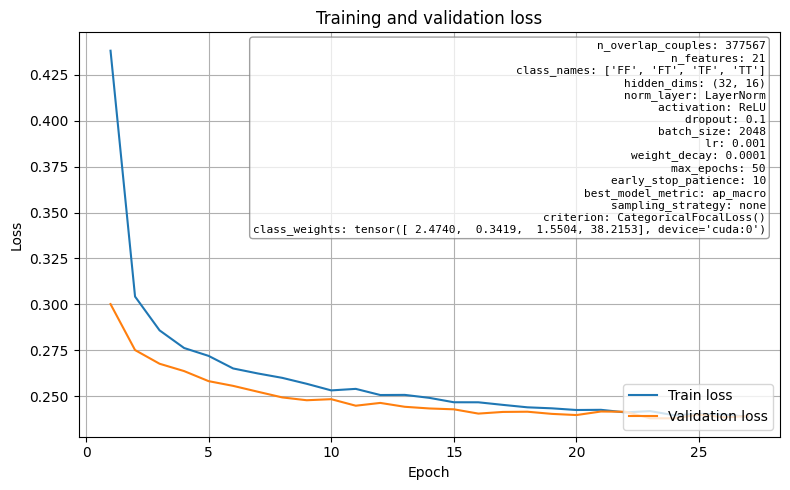

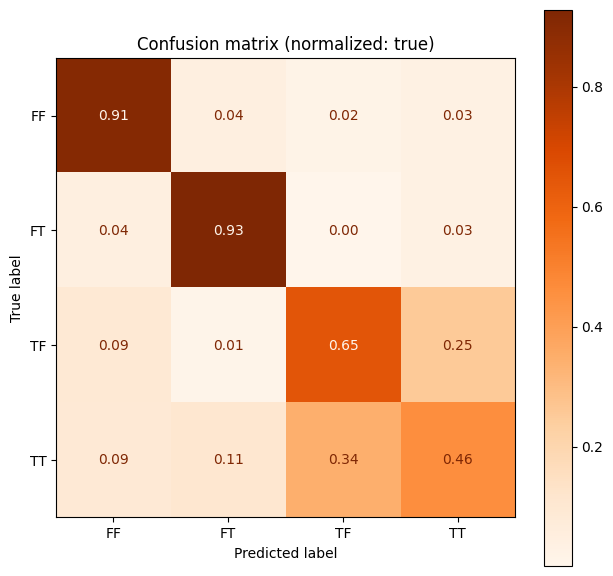

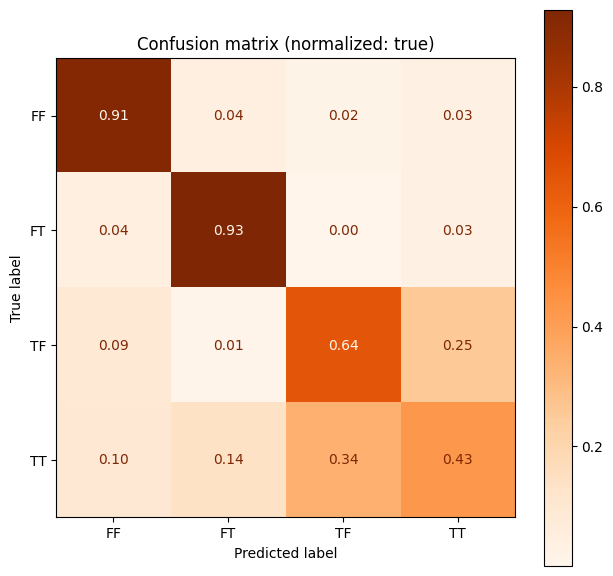

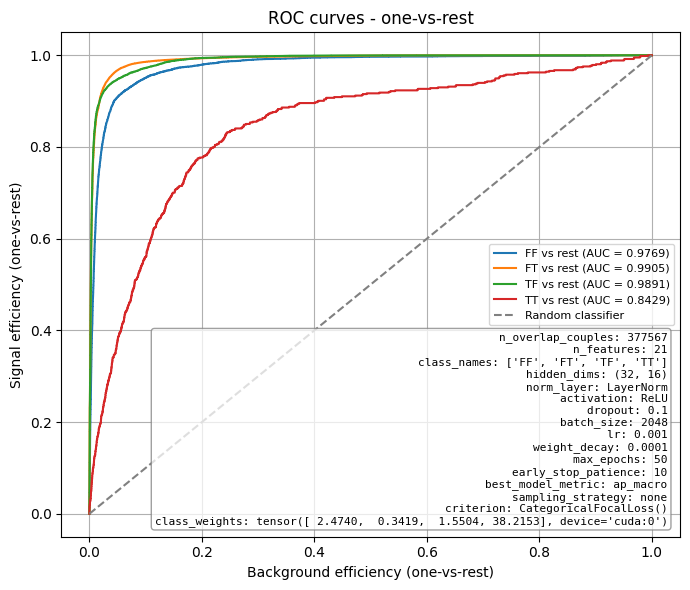

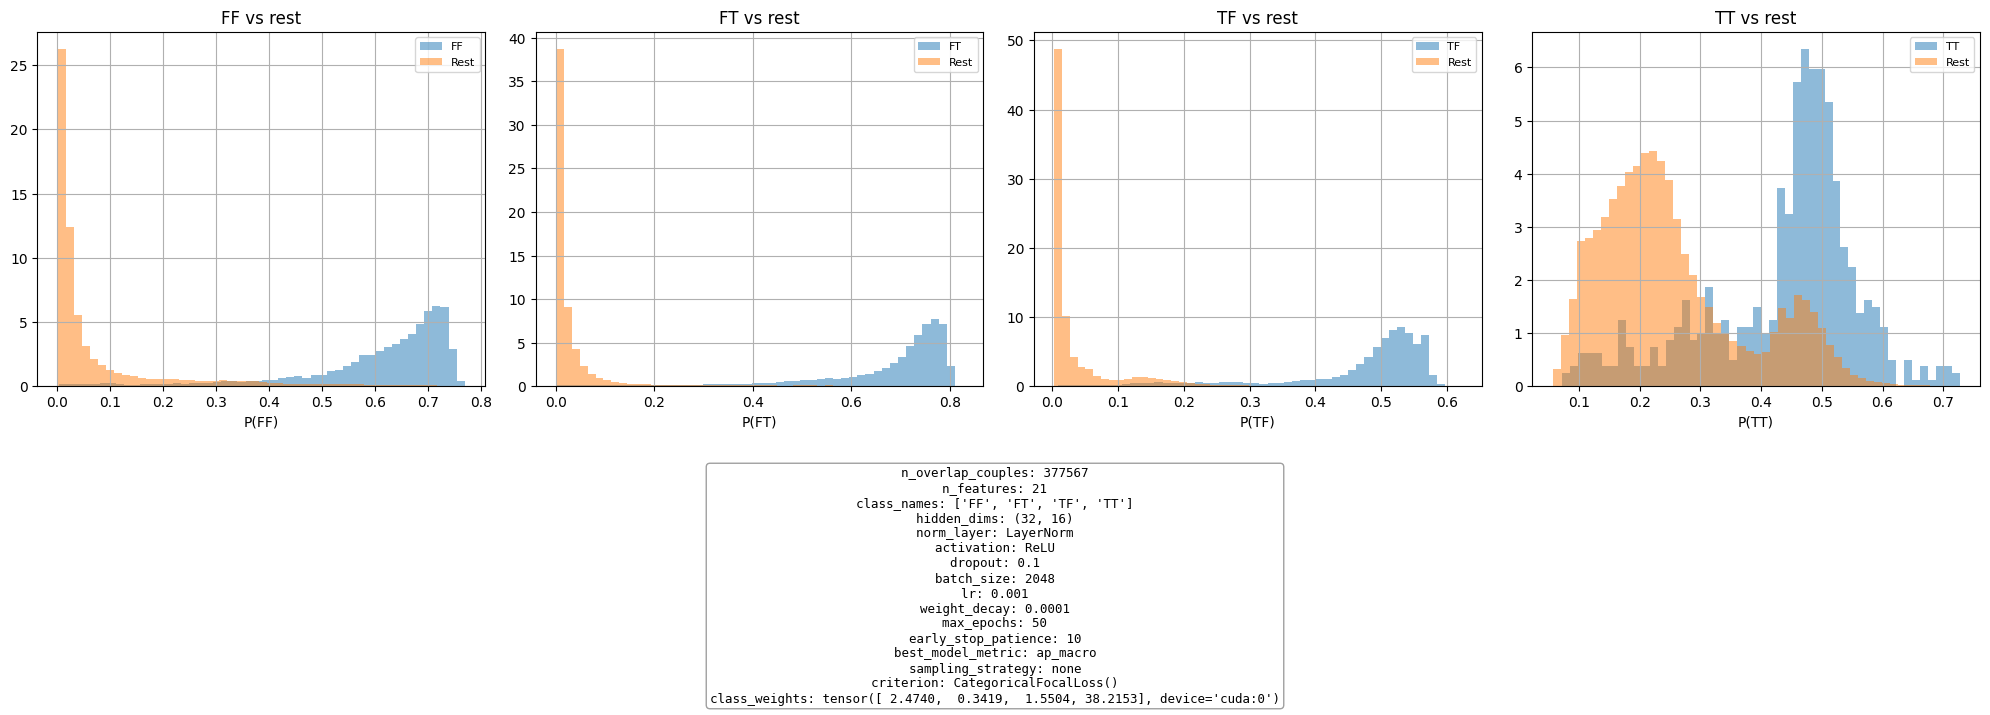

RUN METRICS REPORT - 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
run_tag: 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
timestamp: 2026-09-23T12:13:39

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7312 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  class_weights: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:

In [ ]:
eval_result = run_evaluation_suite(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    train_losses=train_losses,
    val_losses=val_losses,
    device=DEVICE,
    config=config,
    params=PLOT_PARAMS,
    run_name=RUN_TAG,
    run_tag=RUN_TAG,
    graphics_dir=GRAPHICS_DIR,
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    output_subdir=GIT_OUTPUT_DIR,
    class_names=CLASS_NAMES,
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    background_rejection_eff_range=BACKGROUND_REJECTION_EFF_RANGE,
    checkpoint_path=CHECKPOINT_PATH,
)

result = eval_result["push_result"]

In [16]:
#################################################################
# FINE-TUNING FOCAL LOSS: SWEEP alpha_power x gamma
#################################################################
from flavour_tag_ml.fine_tuning import sweep_hyperparameters, plot_alpha_gamma_heatmap

ALPHA_POWERS = [0.0, 0.25, 0.5, 0.75, 1.0]
GAMMAS = [0.0, 1.0, 2.0, 3.0, 5.0]

[focal_a0_g0] già presente sulla repo, salto il training.
[focal_a0_g1] già presente sulla repo, salto il training.
[focal_a0_g2] già presente sulla repo, salto il training.
[focal_a0_g3] già presente sulla repo, salto il training.
[focal_a0_g5] già presente sulla repo, salto il training.
[focal_a0.25_g0] già presente sulla repo, salto il training.
[focal_a0.25_g1] già presente sulla repo, salto il training.
[focal_a0.25_g2] già presente sulla repo, salto il training.
[focal_a0.25_g3] già presente sulla repo, salto il training.
[focal_a0.25_g5] già presente sulla repo, salto il training.
[focal_a0.5_g0] già presente sulla repo, salto il training.
[focal_a0.5_g1] già presente sulla repo, salto il training.
[focal_a0.5_g2] già presente sulla repo, salto il training.
[focal_a0.5_g3] già presente sulla repo, salto il training.
[focal_a0.5_g5] già presente sulla repo, salto il training.
[focal_a0.75_g0] già presente sulla repo, salto il training.
[focal_a0.75_g1] già presente sulla repo, sa

<Axes: title={'center': 'Sweep focal loss — val_ap_TT'}, xlabel='alpha_power  (alpha = class_weights ** alpha_power)', ylabel='gamma'>

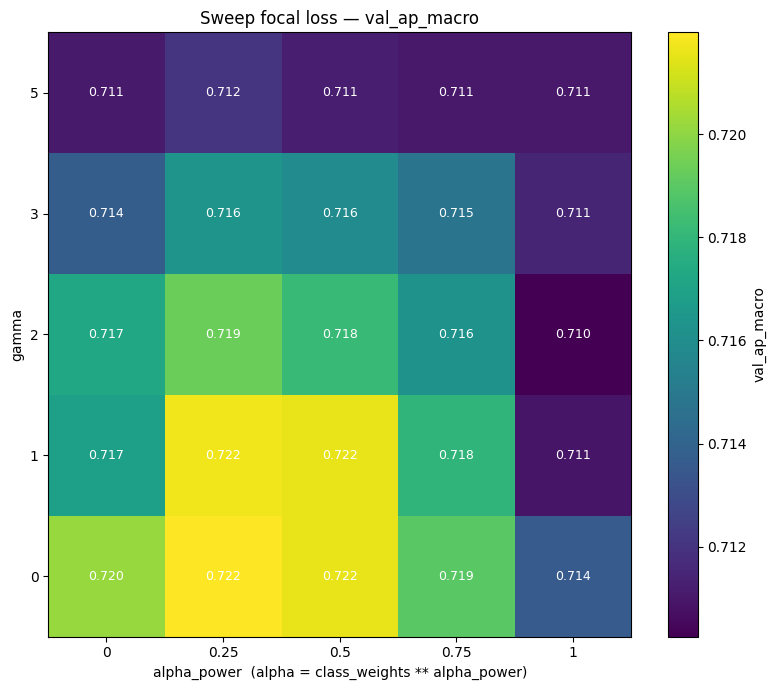

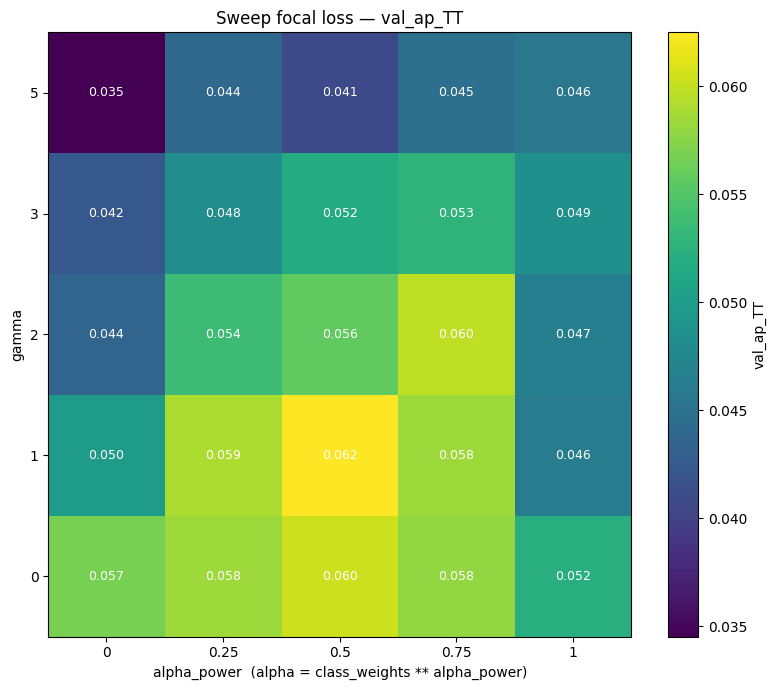

In [17]:

# base_config: solo "data"/"model" (la chiave "training" la costruisce
# sweep_hyperparameters per ogni combo, con alpha_power/gamma/metriche
# incluse esplicitamente - vedi scan_existing_runs).
base_config = {
    "data": config["data"],
    "model": config["model"],
}

results_df = sweep_hyperparameters(
    alpha_powers=ALPHA_POWERS,
    gammas=GAMMAS,
    base_class_weights=CLASS_WEIGHTS,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_factory=lambda: create_model(MODEL_CONFIG, input_dim=X_train.shape[1]),
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    max_epochs=MAX_EPOCHS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    device=DEVICE,
    class_names=CLASS_NAMES,
    graphics_dir=GRAPHICS_DIR,
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    output_subdir=GIT_OUTPUT_DIR,
    base_config=base_config,
    params=PLOT_PARAMS,
    checkpoint_dir=MODEL_DIR,
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    seed=RANDOM_SEED,  # stesso seed per ogni combo - vedi docstring di
                        # train_one_combo per il perche' (isola l'effetto
                        # di alpha/gamma dal rumore di init/ordine dati
                        # dovuto alla condivisione di train_loader/val_loader
                        # tra le combo dello sweep).
)

plot_alpha_gamma_heatmap(results_df, metric="val_ap_macro")
plot_alpha_gamma_heatmap(results_df, metric="val_ap_TT")


In [22]:
#################################################################
# OBIETTIVO 3.4 - PARAMETRI DELLA RUN DI SOLA VALUTAZIONE
#################################################################
# NB: INPUT_DIR deve essere già stato impostato (sopra, a mano) al path
# del NUOVO dataset (es. TTBAR-mc23a-bypass-noOR_mode / la sua versione
# già processata in X_train/val/test_normalized.npy). I nomi dei file
# restano quelli di sempre (TRAINSET_X_NAME, ecc.), dato che il nuovo
# dataset è parametrizzato allo stesso modo di quello di training.

# Tag dedicato per distinguere questa run di sola valutazione dalle run
# di training/sweep dell'obiettivo 3.3 (stesso RUN_TAG userebbe, per il
# glob su *{run_tag}*, le figure già presenti in GRAPHICS_DIR - meglio
# tenerle separate).
EVAL_DATASET_TAG = "EVAL_bkg_tt"
EVAL_RUN_TAG = f"{RUN_TAG}_{EVAL_DATASET_TAG}"
EVAL_RUN_NAME = EVAL_RUN_TAG

# Cartella locale separata per i grafici di questa valutazione (evita di
# mischiare i file con quelli dell'obiettivo 3.3 in GRAPHICS_DIR)
EVAL_GRAPHICS_DIR = os.path.join(os.path.dirname(GRAPHICS_DIR), f"{EVAL_DATASET_TAG}")
os.makedirs(EVAL_GRAPHICS_DIR, exist_ok=True)

# Sottocartella dedicata sulla repo GitHub (stesso repo/output tree di
# sempre, ma percorso diverso da GIT_OUTPUT_DIR così da non toccare gli
# output del training)
EVAL_GIT_OUTPUT_DIR = f"DNN/{EVAL_DATASET_TAG}"

print("INPUT_DIR (nuovo dataset):", INPUT_DIR)
print("EVAL_RUN_TAG:", EVAL_RUN_TAG)
print("EVAL_GRAPHICS_DIR:", EVAL_GRAPHICS_DIR)
print("EVAL_GIT_OUTPUT_DIR:", EVAL_GIT_OUTPUT_DIR)

INPUT_DIR (nuovo dataset): /content/drive/MyDrive/overlap_resolver/datas/np_arrays/bkg_tt
EVAL_RUN_TAG: 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt
EVAL_GRAPHICS_DIR: /content/drive/MyDrive/overlap_resolver/graphics/model_eval/EVAL_bkg_tt
EVAL_GIT_OUTPUT_DIR: DNN/EVAL_bkg_tt


In [23]:
# CARICAMENTO NUOVO DATASET (i 3 split verranno unificati: qui li carichiamo
# solo, senza toccare X_train/y_train/... del dataset di training originale,
# che serve ancora se si vuole confrontare le due valutazioni)

X_train_new = load_mmap(INPUT_DIR, TRAINSET_X_NAME)
y_train_new = load_mmap(INPUT_DIR, TRAINSET_Y_NAME)

X_val_new = load_mmap(INPUT_DIR, VALSET_X_NAME)
y_val_new = load_mmap(INPUT_DIR, VALSET_Y_NAME)

X_test_new = load_mmap(INPUT_DIR, TESTSET_X_NAME)
y_test_new = load_mmap(INPUT_DIR, TESTSET_Y_NAME)

print("Nuovo dataset - shapes originarie per split:")
print("  train:", X_train_new.shape, y_train_new.shape)
print("  val:  ", X_val_new.shape, y_val_new.shape)
print("  test: ", X_test_new.shape, y_test_new.shape)

assert X_train_new.shape[1] == X_val_new.shape[1] == X_test_new.shape[1], (
    "Numero di feature diverso tra gli split del nuovo dataset!"
)
assert X_train_new.shape[1] == X_train.shape[1], (
    "Il nuovo dataset ha un numero di feature diverso da quello su cui è "
    "stato allenato il modello: non è valutabile con questo modello."
)

Nuovo dataset - shapes originarie per split:
  train: (71696, 21) (71696,)
  val:   (15334, 21) (15334,)
  test:  (15438, 21) (15438,)


In [24]:
# UNIFICAZIONE train+val+test DEL NUOVO DATASET IN UN UNICO BLOCCO DI VALUTAZIONE
#
# Qui non c'è più bisogno di uno split train/val/test: l'intero nuovo
# dataset va usato solo per fare inferenza col modello già allenato, quindi
# lo trattiamo come un unico "test set esterno". I tre array sono mmap
# (load_mmap -> np.load(..., mmap_mode='r')): np.concatenate li legge
# interamente in RAM, quindi se il nuovo dataset è molto grande valutare
# se servono batch/chunking; per dataset di dimensioni comparabili a
# quello di training questo è sufficiente.

X_eval = np.concatenate([X_train_new, X_val_new, X_test_new], axis=0)
y_eval = np.concatenate([y_train_new, y_val_new, y_test_new], axis=0)

print("Dataset di valutazione unificato (ex train+val+test):", X_eval.shape, y_eval.shape)
print("Bilanciamento classi (frazione per classe):")
for i, cname in enumerate(CLASS_NAMES):
    print(f"  {cname}: {np.mean(y_eval == i):.4f}")

# Libera i riferimenti agli split intermedi (restano comunque gli originali
# X_train/y_train/... del dataset di training, usati altrove nel notebook)
del X_train_new, y_train_new, X_val_new, y_val_new, X_test_new, y_test_new

Dataset di valutazione unificato (ex train+val+test): (102468, 21) (102468,)
Bilanciamento classi (frazione per classe):
  FF: 0.7502
  FT: 0.0007
  TF: 0.2430
  TT: 0.0062


In [25]:
# Dataset PyTorch di sola valutazione (nessuno split, nessun training):
# task/tipizzazione coerenti con quanto già validato in fase di training.

eval_dataset = JetDataset(X_eval, y_eval, task=TASK)

assert eval_dataset.y.dtype == (torch.long if TASK == "multiclass" else torch.float32)
assert set(torch.unique(eval_dataset.y).tolist()) <= set(range(NUM_CLASSES))

# DataLoader semplice e sequenziale: niente sampler/shuffle/rebalancing,
# dato che non stiamo allenando nulla, solo calcolando predizioni.
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [28]:
# Se il modello allenato nell'obiettivo 3.3 è ancora in memoria (variabile
# `model`, uscita da train_model), questa cella non serve. Se invece il
# kernel è stato riavviato, decommentare per ricaricare i pesi migliori
# salvati su MODEL_PATH.

model = create_model(MODEL_CONFIG, input_dim=X_eval.shape[1])
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
print(f"Modello ricaricato da: {MODEL_PATH}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/overlap_resolver/models/HH_bbtt_dataset/best_model_2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none.pt'

mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


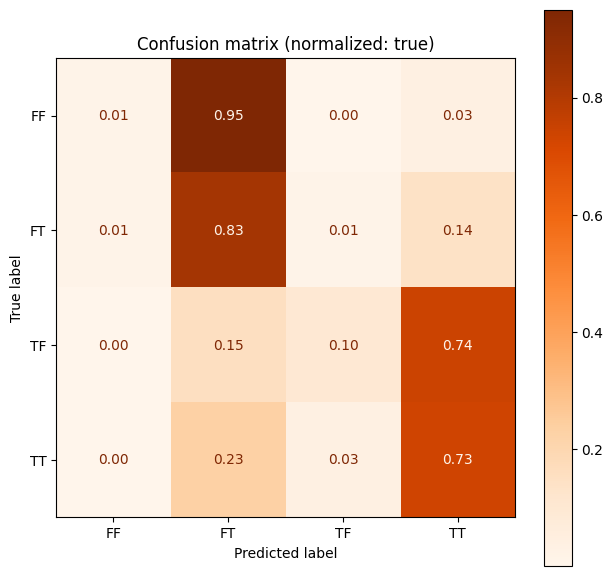

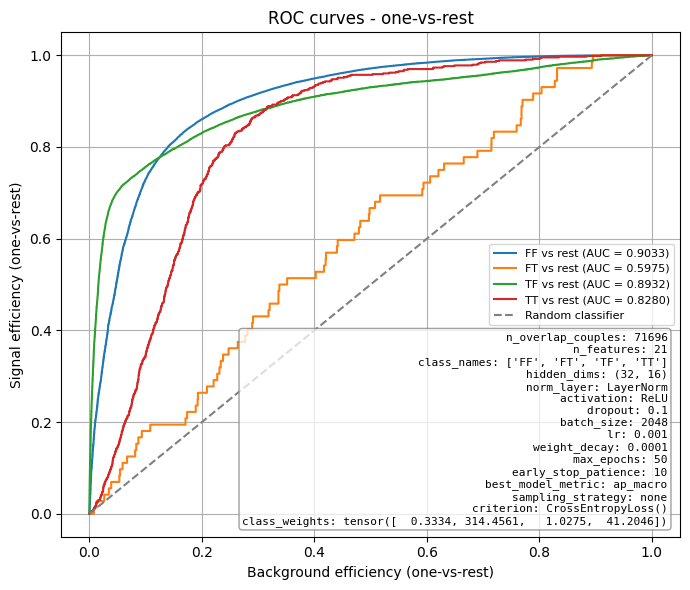

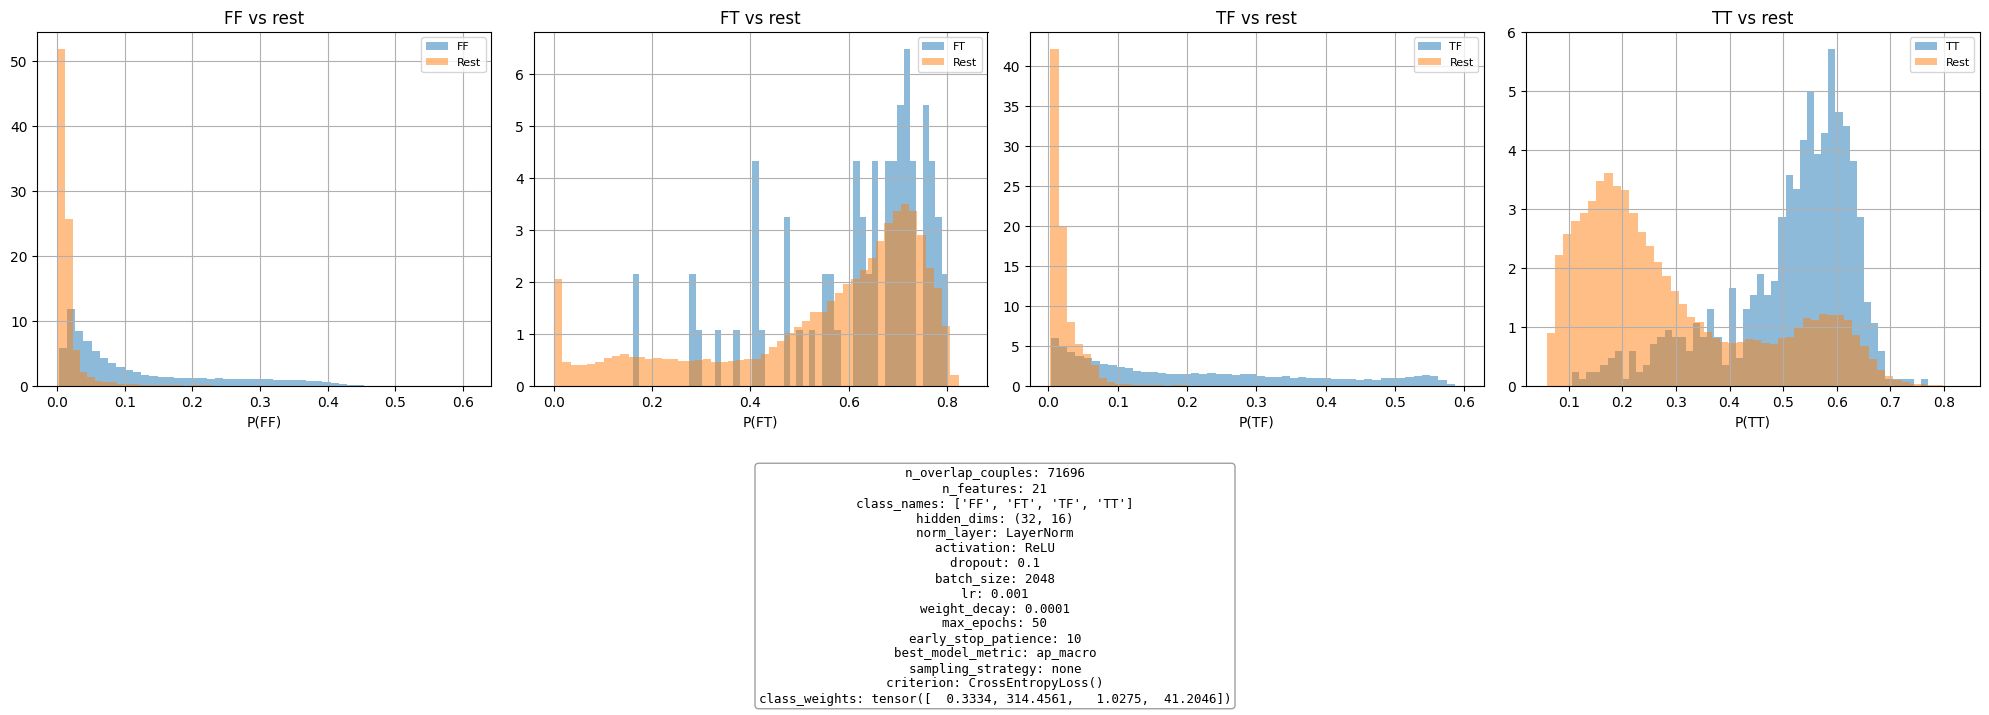

In [18]:
#################################################################
# INFERENZA + METRICHE + GRAFICI SUL NUOVO DATASET (solo eval, no train)
#################################################################
# Riusiamo le stesse funzioni di basso livello usate da run_evaluation_suite,
# ma senza passare da run_evaluation_suite stessa: quella funzione si aspetta
# SEMPRE sia un train_loader sia un test_loader (calcola e riporta metriche/
# grafici per entrambi), mentre qui non esiste alcun training set da
# valutare - solo il nuovo dataset, trattato integralmente come test.

if ATLAS_STYLE:
    apply_atlas_style()

eval_labels, eval_scores, _, eval_pred = get_predictions(model, eval_loader, DEVICE)

plot_multiclass_confusion_matrix(
    eval_labels, eval_pred, CLASS_NAMES, normalize="true",
    save_dir=EVAL_GRAPHICS_DIR, filename=f"confusion_matrix_eval_{EVAL_RUN_TAG}",
)

ovr_eval = plot_ovr_roc_curves(
    eval_labels, eval_scores, CLASS_NAMES,
    save_dir=EVAL_GRAPHICS_DIR, filename=f"roc_curve_eval_{EVAL_RUN_TAG}",
    params=PLOT_PARAMS, atlas_label=ATLAS_STYLE,
)

plot_multiclass_score_distribution(
    eval_labels, eval_scores, CLASS_NAMES,
    save_dir=EVAL_GRAPHICS_DIR, filename=f"score_distribution_eval_{EVAL_RUN_TAG}",
    params=PLOT_PARAMS, atlas_label=ATLAS_STYLE,
)

eval_working_points = compute_ovr_working_points(
    eval_labels, eval_scores, CLASS_NAMES, target_effs=WORKING_POINT_TARGETS,
)

eval_metrics = compute_multiclass_classification_metrics(eval_labels, eval_pred, CLASS_NAMES)

eval_class_balance = {
    "eval": {name: float(np.mean(eval_labels == i)) for i, name in enumerate(CLASS_NAMES)},
}

param_counts = count_model_parameters(model)

eval_arrays_path = save_run_arrays(
    EVAL_GRAPHICS_DIR, f"run_arrays_{EVAL_RUN_TAG}",
    run_name=EVAL_RUN_NAME, run_tag=EVAL_RUN_TAG,
    eval_labels=eval_labels, eval_scores=eval_scores,
    working_points=eval_working_points,
)

In [19]:
#################################################################
# REPORT TESTUALE (senza sezione train, non esiste in questo caso) + PUSH SU GITHUB
#################################################################

eval_config = {
    "data": {
        "input_dir": INPUT_DIR,
        "trainset_x_name": TRAINSET_X_NAME,
        "trainset_y_name": TRAINSET_Y_NAME,
        "valset_x_name": VALSET_X_NAME,
        "valset_y_name": VALSET_Y_NAME,
        "testset_x_name": TESTSET_X_NAME,
        "testset_y_name": TESTSET_Y_NAME,
        "note": (
            "Dataset esterno al training: train+val+test di INPUT_DIR sono "
            "stati unificati in un unico blocco usato SOLO per valutazione "
            "(nessun training/fine-tuning eseguito su questi dati)."
        ),
        "n_eval": int(X_eval.shape[0]),
        "n_features": int(X_eval.shape[1]),
        "class_names": CLASS_NAMES,
    },
    "model": {
        **MODEL_CONFIG,
        "activ_func": ACTIV_FUNC.__class__.__name__,
        "source_model_path": MODEL_PATH,
        "source_run_tag": RUN_TAG,  # run di training (obiettivo 3.3) da cui vengono i pesi
    },
    "training": {
        "note": "Nessun training in questa run: solo inferenza/valutazione.",
    },
    "paths": {
        "model_dir": MODEL_DIR,
        "model_name": MODEL_NAME,
        "model_path": MODEL_PATH,
        "graphics_dir": EVAL_GRAPHICS_DIR,
    },
    "other": {
        "random_seed": RANDOM_SEED,
        "device": str(DEVICE),
        "atlas_style": ATLAS_STYLE,
        "working_point_targets": WORKING_POINT_TARGETS,
    },
}

def build_external_eval_report(run_name, run_tag, config, eval_metrics, working_points,
                                param_counts, class_names, class_balance):
    """Report minimale per una run di sola valutazione (nessun train set).

    Stessa struttura di build_metrics_report, ma con una sola sezione
    risultati ("Eval set", il dataset esterno unificato) invece di
    Train/Test, e senza sezione Training (nessuna storia di loss/epoche
    da riportare).    """
    lines = []

    def h(title):
        lines.append("")
        lines.append(title)
        lines.append("-" * len(title))

    header = f"RUN METRICS REPORT (EXTERNAL EVAL) - {run_name}"
    lines.append(header)
    lines.append("=" * len(header))
    lines.append(f"run_tag: {run_tag}")
    #lines.append(f"timestamp: {datetime.now().isoformat(timespec='seconds')}")
    lines.append(config["data"].get("note", ""))

    h("Dataset")
    data_cfg = config.get("data", {})
    lines.append(f"  input_dir: {data_cfg.get('input_dir')}")
    lines.append(f"  n_eval: {data_cfg.get('n_eval')} | n_features: {data_cfg.get('n_features')}")
    for split, fracs in class_balance.items():
        frac_str = " | ".join(f"{cname}: {v:.4f}" for cname, v in fracs.items())
        lines.append(f"  class balance {split} (frazione per classe): {frac_str}")

    h("Modello (pesi provenienti da un'altra run)")
    model_cfg = config.get("model", {})
    for k, v in model_cfg.items():
        lines.append(f"  {k}: {v}")
    lines.append(f"  n_parametri_totali: {param_counts['n_parameters_total']}")
    lines.append(f"  n_parametri_allenabili: {param_counts['n_parameters_trainable']}")

    h("Training")
    lines.append(f"  {config['training'].get('note', '')}")

    h("Risultati - Eval set (multiclasse, dataset esterno unificato)")
    m = eval_metrics
    lines.append(f"  n_totale: {m['n_total']}")
    lines.append(f"  accuracy: {m['accuracy'] * 100:.2f}%")
    lines.append(f"  {'classe':>6} {'precision':>10} {'recall':>10} {'f1':>10} {'support':>10}")
    for cname in class_names:
        pc = m["per_class"][cname]
        lines.append(
            f"  {cname:>6} {pc['precision']*100:>9.2f}% {pc['recall']*100:>9.2f}% "
            f"{pc['f1']:>10.4f} {pc['support']:>10d}"
        )
    lines.append(f"  macro avg   - precision: {m['macro_avg']['precision']*100:.2f}%  "
                 f"recall: {m['macro_avg']['recall']*100:.2f}%  f1: {m['macro_avg']['f1']:.4f}")
    lines.append(f"  weighted avg- precision: {m['weighted_avg']['precision']*100:.2f}%  "
                 f"recall: {m['weighted_avg']['recall']*100:.2f}%  f1: {m['weighted_avg']['f1']:.4f}")

    h("Working points one-vs-rest (eval set) - efficienza di segnale fissata")
    for cname in class_names:
        lines.append(f"\n  --- classe: {cname} ---")
        lines.append(
            f"  {'sig. eff. WP':>12} {'threshold':>10} {'eff. reale':>12} "
            f"{'bkg eff.':>10} {'bkg rejection':>14}"
        )
        for wp in working_points[cname]["working_points"]:
            rej = wp["background_rejection"]
            rej_str = f"{rej:.2f}" if np.isfinite(rej) else "inf"
            lines.append(
                f"  {wp['target_efficiency'] * 100:>11.0f}% "
                f"{wp['threshold']:>10.4f} "
                f"{wp['achieved_efficiency'] * 100:>11.2f}% "
                f"{wp['background_efficiency'] * 100:>9.2f}% "
                f"{rej_str:>14}"
            )

    lines.append("")
    return "\n".join(lines)

eval_report_text = build_external_eval_report(
    run_name=EVAL_RUN_NAME,
    run_tag=EVAL_RUN_TAG,
    config=eval_config,
    eval_metrics=eval_metrics,
    working_points=eval_working_points,
    param_counts=param_counts,
    class_names=CLASS_NAMES,
    class_balance=eval_class_balance,
)
eval_report_path = write_metrics_report(eval_report_text, EVAL_GRAPHICS_DIR, f"metrics_report_{EVAL_RUN_TAG}")
print(eval_report_text)

RUN METRICS REPORT (EXTERNAL EVAL) - 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt
run_tag: 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt
Dataset esterno al training: train+val+test di INPUT_DIR sono stati unificati in un unico blocco usato SOLO per valutazione (nessun training/fine-tuning eseguito su questi dati).

Dataset
-------
  input_dir: /content/drive/MyDrive/overlap_resolver/datas/np_arrays/bkg_tt
  n_eval: 102468 | n_features: 21
  class balance eval (frazione per classe): FF: 0.7502 | FT: 0.0007 | TF: 0.2430 | TT: 0.0062

Modello (pesi provenienti da un'altra run)
------------------------------------------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  a

In [20]:
# Push di figure + config.yaml + report sulla repo GitHub (stessa funzione
# di sempre - non richiede train/test loader, solo run_tag/graphics_dir/config)

eval_push_result = save_run_outputs(
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    run_name=EVAL_RUN_NAME,
    run_tag=EVAL_RUN_TAG,
    output_subdir=EVAL_GIT_OUTPUT_DIR,
    graphics_dir=EVAL_GRAPHICS_DIR,
    config=eval_config,
)

eval_push_result

Copiate 6 figure in /content/overlap_resolver/outputs/DNN/EVAL_bkg_tt/2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt/figures
Copiati 1 file di report testuale in /content/overlap_resolver/outputs/DNN/EVAL_bkg_tt/2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt
Copiati 1 file di dati (.npz) in /content/overlap_resolver/outputs/DNN/EVAL_bkg_tt/2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt
Config salvato in /content/overlap_resolver/outputs/DNN/EVAL_bkg_tt/2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt/config.yaml


{'run_output_dir': '/content/overlap_resolver/outputs/DNN/EVAL_bkg_tt/2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt',
 'config_path': '/content/overlap_resolver/outputs/DNN/EVAL_bkg_tt/2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CrossEntropyLoss()_weight_loss_True_sampling_strategy_none_EVAL_bkg_tt/config.yaml',
 'n_figures_copied': 6,
 'n_reports_copied': 1,
 'n_data_files_copied': 1}